# Makemore Bigram name Generator
I'll try this with the dataset already shipped on github and then I'll create my own.

In [2]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

NOTE:
*Some part of code uses cuda acceleration it will work for you both ways because I added check if you have cuda or not but it might run little slower I thought it might be nice thing to say so that anyone reading this gets warned beforehand :P. Below you can check if you will use cuda acceleration or not.*

In [209]:
if torch.cuda.is_available():
    n = torch.cuda.device_count()
    print(f'Found {n} {"GPUs" if n > 1 else "GPU"}:')
    for i in range(n):
        prop = torch.cuda.get_device_properties(i)
        print(f'GPU({i}): VRAM {prop.total_memory/(1024**3):.2f}GB - {prop.name} is available.')
else:
    print("No GPU available. Training will run on CPU.")

Found 1 GPU:
GPU(0): VRAM 6.00GB - NVIDIA GeForce GTX 1660 SUPER is available.


## Dataset from github

In [3]:
general_names = open('data/text/general-names.txt', 'r').read().splitlines()

In [4]:
print('general_names')
print('len', len(general_names))
print('min', min(len(w) for w in general_names))
print('max', max(len(w) for w in general_names))

general_names
len 32033
min 2
max 15


In [5]:
bgn = {}
for w in general_names:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    bigram = (ch1, ch2)
    bgn[bigram] = bgn.get(bigram, 0) + 1

In [6]:
sorted(bgn.items(), key = lambda kv: -kv[1])

[(('n', '.'), 6763),
 (('a', '.'), 6640),
 (('a', 'n'), 5438),
 (('.', 'a'), 4410),
 (('e', '.'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('.', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('.', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '.'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('.', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '.'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('.', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '.'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('.', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('.', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('.', 'l'), 1572),
 (('.', 'c'), 1542),
 (('.', 'e'), 1531),
 (('j', 'a'), 1473),
 (('r', '.'), 1377),
 (('n', 'e'),

In [44]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [45]:
chars = sorted(list(set(''.join(general_names))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [46]:
for w in general_names:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

### Dataset visualization

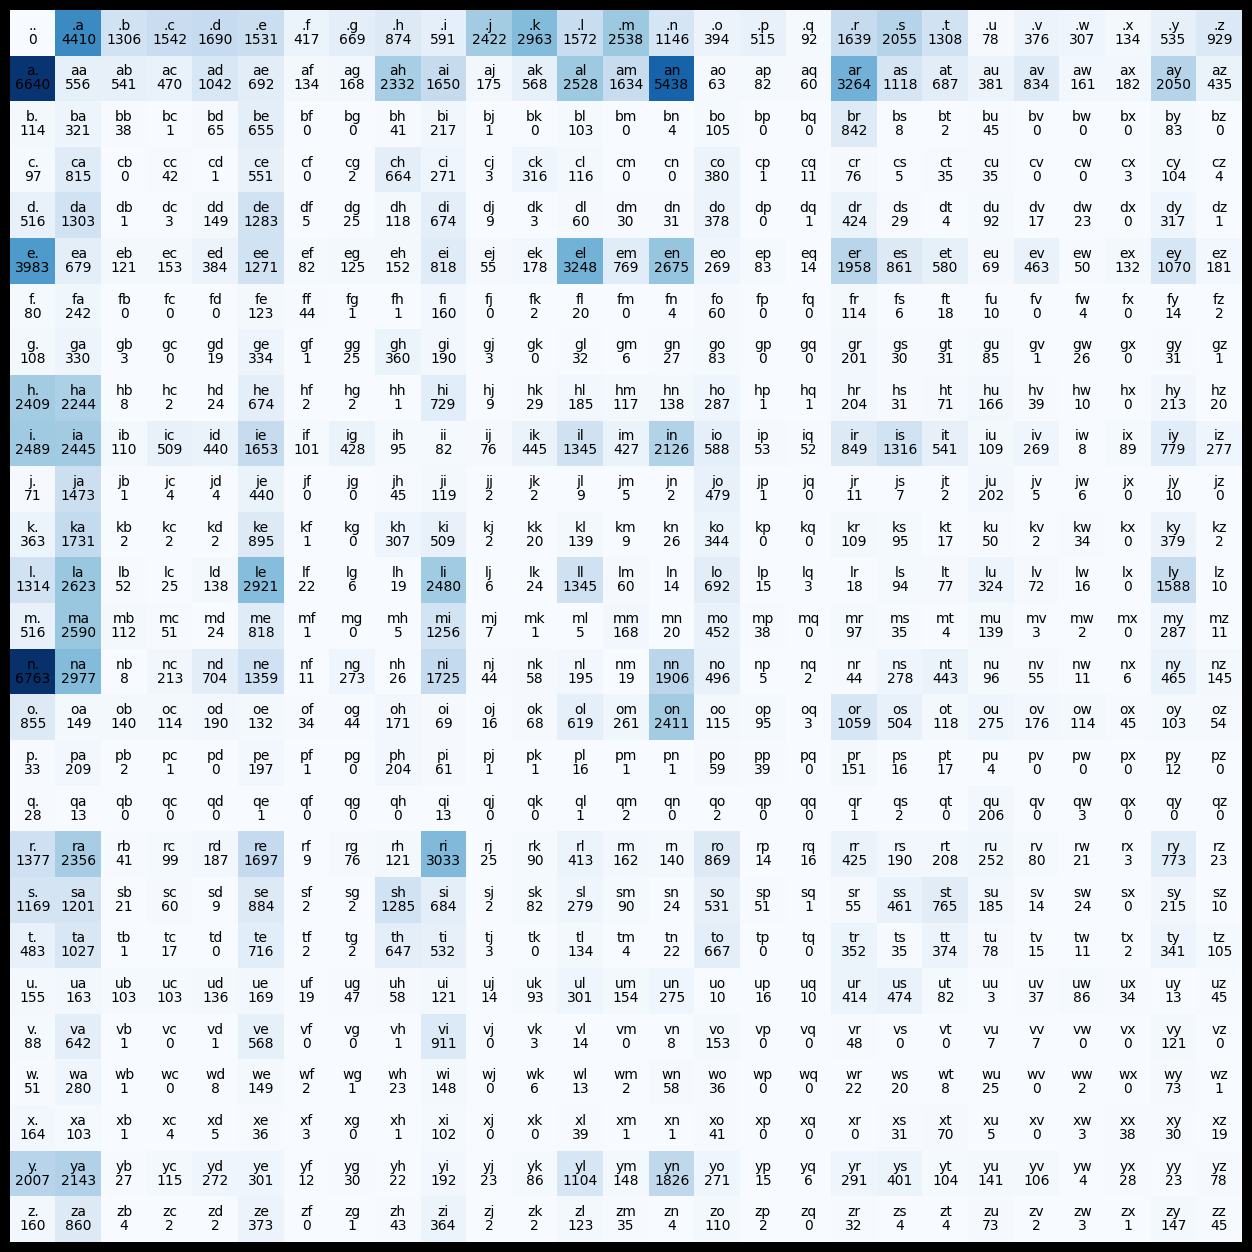

In [47]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='black')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='black')
plt.axis('off');

In [37]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [12]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [48]:
P = (N+1).float()
P /= P.sum(1, keepdims=True)
P

tensor([[3.1192e-05, 1.3759e-01, 4.0767e-02, 4.8129e-02, 5.2745e-02, 4.7785e-02,
         1.3038e-02, 2.0898e-02, 2.7293e-02, 1.8465e-02, 7.5577e-02, 9.2452e-02,
         4.9064e-02, 7.9195e-02, 3.5777e-02, 1.2321e-02, 1.6095e-02, 2.9008e-03,
         5.1154e-02, 6.4130e-02, 4.0830e-02, 2.4641e-03, 1.1759e-02, 9.6070e-03,
         4.2109e-03, 1.6719e-02, 2.9008e-02],
        [1.9583e-01, 1.6425e-02, 1.5983e-02, 1.3889e-02, 3.0756e-02, 2.0435e-02,
         3.9809e-03, 4.9835e-03, 6.8796e-02, 4.8685e-02, 5.1899e-03, 1.6779e-02,
         7.4575e-02, 4.8213e-02, 1.6039e-01, 1.8872e-03, 2.4475e-03, 1.7988e-03,
         9.6279e-02, 3.2997e-02, 2.0288e-02, 1.1264e-02, 2.4623e-02, 4.7771e-03,
         5.3963e-03, 6.0480e-02, 1.2857e-02],
        [4.3039e-02, 1.2051e-01, 1.4596e-02, 7.4850e-04, 2.4701e-02, 2.4551e-01,
         3.7425e-04, 3.7425e-04, 1.5719e-02, 8.1587e-02, 7.4850e-04, 3.7425e-04,
         3.8922e-02, 3.7425e-04, 1.8713e-03, 3.9671e-02, 3.7425e-04, 3.7425e-04,
         3.1549e-

### First generation try

In [49]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):

  out = []
  ix = 0
  while True:
    p = N[ix].float()
    p = p / p.sum()
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


Now the result is not something that looks good. So we will try to improve it by training it further...

### Training the Bigram Model
The goal is to maximize likelihood of the data w.r.t. model parameters (statistical modeling) which also means:
- maximize the log likelihood (because log is monotonic)
- minimize the negative log likelihood
- minimize the average negative log likelihood

*log(a\*b\*c) = log(a) + log(b) + log(c)*

In [218]:
log_likelihood = 0.0
n = 0

for w in general_names:
#for w in ["andrejq"]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1
    #print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


In [219]:
xs, ys = [], []

for w in general_names[:1]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    print(ch1, ch2)
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [220]:
xs

tensor([ 0,  5, 13, 13,  1])

In [221]:
ys

tensor([ 5, 13, 13,  1,  0])

In [222]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [223]:
xenc.shape

torch.Size([5, 27])

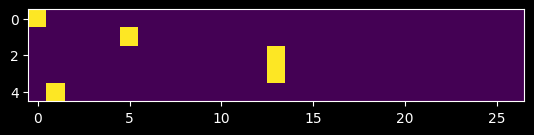

In [224]:
plt.imshow(xenc)

In [225]:
xenc.dtype

torch.float32

In [227]:
W = torch.randn((27,1))
xenc @ W

tensor([[-0.1873],
        [ 0.0189],
        [ 0.0809],
        [ 0.0809],
        [ 0.0024]])

In [230]:
g = torch.Generator().manual_seed(2147483647 + 2)
W = torch.randn((27, 27), generator=g)

In [231]:
xenc = F.one_hot(xs, num_classes=27).float()
if torch.cuda.is_available():
    xenc.to('cuda')
# input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
# btw: the last 2 lines here are together called a 'softmax'

In [232]:
probs.shape

torch.Size([5, 27])

In [233]:
nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0111, 0.0226, 0.0473, 0.0139, 0.0086, 0.0413, 0.0333, 0.0078, 0.0392,
        0.0017, 0.0126, 0.0582, 0.0178, 0.0157, 0.0409, 0.1413, 0.0191, 0.0229,
        0.0704, 0.2134, 0.0123, 0.0008, 0.0058, 0.1115, 0.0037, 0.0147, 0.0120])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.04132620245218277
log likelihood: -3.186258554458618
negative log likelihood: 3.186258554458618
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0183, 0.0296, 0.0311, 0.0553, 0.0236, 0.0401, 0.0184, 0.0303, 0.0160,
        0.0133, 0.0393, 0.0081, 0.1678, 0.0214, 0.0285, 0.0040, 0.1159, 0.0166,
        0.0073, 0.0446, 0.0226, 0.1627, 0.0117, 0.0225, 0.0215, 0.0205, 0.0090])
label (actual next character): 13
probability assigned by the net to the the correct character: 0.

And finally some optimizations:

In [256]:
# create the dataset
xs, ys = [], []
for w in general_names:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator(device=torch.device('cuda') if torch.cuda.is_available() else None).manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True, device=torch.device('cuda') if torch.cuda.is_available() else None)

number of examples:  228146


In [263]:
# gradient descent
for k in range(1000):

  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  if torch.cuda.is_available():
    xenc = xenc.to('cuda')
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  print(loss.item())

  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()

  # update
  W.data += -50 * W.grad

2.4804461002349854
2.4804461002349854
2.4804458618164062
2.4804458618164062
2.480445384979248
2.480445146560669
2.480445146560669
2.480445146560669
2.48044490814209
2.4804446697235107
2.4804446697235107
2.4804444313049316
2.4804441928863525
2.4804441928863525
2.4804439544677734
2.4804439544677734
2.4804437160491943
2.4804434776306152
2.480443239212036
2.4804434776306152
2.480443239212036
2.480443000793457
2.480443000793457
2.480442523956299
2.480442762374878
2.4804420471191406
2.4804422855377197
2.4804420471191406
2.4804420471191406
2.4804418087005615
2.4804418087005615
2.4804418087005615
2.4804415702819824
2.4804413318634033
2.480441093444824
2.480441093444824
2.480440855026245
2.480440855026245
2.480440616607666
2.480440378189087
2.480440139770508
2.480440139770508
2.4804399013519287
2.4804399013519287
2.4804396629333496
2.4804396629333496
2.4804396629333496
2.4804396629333496
2.4804391860961914
2.4804389476776123
2.4804389476776123
2.480438709259033
2.4804389476776123
2.480438470840

In [270]:
# finally, sample from the 'neural net' model
g = torch.Generator(device=torch.device('cuda') if torch.cuda.is_available() else None).manual_seed(torch.seed())

for i in range(10):

  out = []
  ix = 0
  while True:

    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    if torch.cuda.is_available():
      xenc = xenc.to('cuda')

    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------


    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

niga.
migrlaey.
jafadyi.
x.
tiezlovelarren.
s.
kalian.
jonaben.
jarzualiy.
zaxstlazonale.


---
# My custom webscrapped dataset #01

In [14]:
web_general_names = open('data/text/webscrapped-general-names.txt', 'r').read().splitlines()

In [15]:
print('web_general_names')
print('len', len(web_general_names))
print('min', min(len(w) for w in web_general_names))
print('max', max(len(w) for w in web_general_names))

web_general_names
len 25583
min 1
max 18


In [16]:
bwgn = {}
for w in general_names:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    bigram = (ch1, ch2)
    bwgn[bigram] = bwgn.get(bigram, 0) + 1

In [17]:
sorted(bwgn.items(), key = lambda kv: -kv[1])

[(('n', '.'), 6763),
 (('a', '.'), 6640),
 (('a', 'n'), 5438),
 (('.', 'a'), 4410),
 (('e', '.'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('.', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('.', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '.'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('.', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '.'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('.', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '.'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('.', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('.', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('.', 'l'), 1572),
 (('.', 'c'), 1542),
 (('.', 'e'), 1531),
 (('j', 'a'), 1473),
 (('r', '.'), 1377),
 (('n', 'e'),

In [27]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [28]:
chars = sorted(list(set(''.join(web_general_names))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [29]:
for w in web_general_names:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

### Dataset visualization

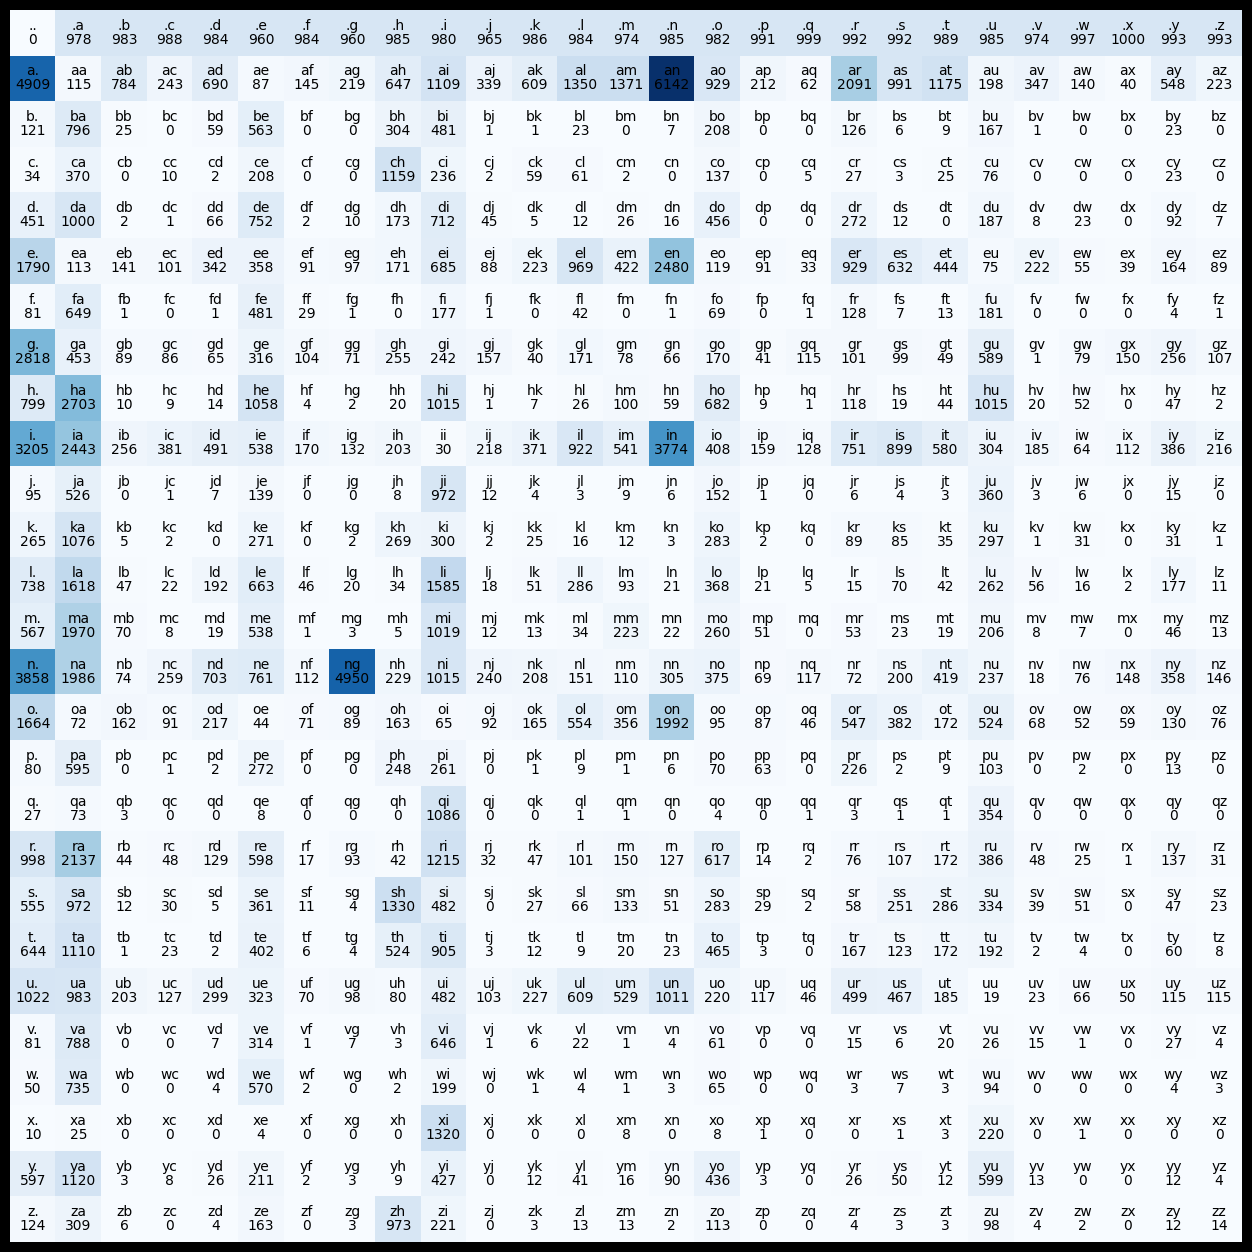

In [30]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='black')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='black')
plt.axis('off');

In [31]:
N[0]

tensor([   0,  978,  983,  988,  984,  960,  984,  960,  985,  980,  965,  986,
         984,  974,  985,  982,  991,  999,  992,  992,  989,  985,  974,  997,
        1000,  993,  993], dtype=torch.int32)

In [23]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.0382, 0.0384, 0.0386, 0.0385, 0.0375, 0.0385, 0.0375, 0.0385,
        0.0383, 0.0377, 0.0385, 0.0385, 0.0381, 0.0385, 0.0384, 0.0387, 0.0390,
        0.0388, 0.0388, 0.0387, 0.0385, 0.0381, 0.0390, 0.0391, 0.0388, 0.0388])

In [32]:
P = (N+1).float()
P /= P.sum(1, keepdims=True)
P

tensor([[3.9047e-05, 3.8227e-02, 3.8422e-02, 3.8618e-02, 3.8462e-02, 3.7524e-02,
         3.8462e-02, 3.7524e-02, 3.8501e-02, 3.8305e-02, 3.7720e-02, 3.8540e-02,
         3.8462e-02, 3.8071e-02, 3.8501e-02, 3.8383e-02, 3.8735e-02, 3.9047e-02,
         3.8774e-02, 3.8774e-02, 3.8657e-02, 3.8501e-02, 3.8071e-02, 3.8969e-02,
         3.9086e-02, 3.8813e-02, 3.8813e-02],
        [1.9074e-01, 4.5063e-03, 3.0495e-02, 9.4787e-03, 2.6843e-02, 3.4185e-03,
         5.6717e-03, 8.5463e-03, 2.5173e-02, 4.3120e-02, 1.3208e-02, 2.3697e-02,
         5.2482e-02, 5.3298e-02, 2.3864e-01, 3.6128e-02, 8.2744e-03, 2.4474e-03,
         8.1268e-02, 3.8536e-02, 4.5684e-02, 7.7306e-03, 1.3519e-02, 5.4774e-03,
         1.5927e-03, 2.1327e-02, 8.7017e-03],
        [4.1384e-02, 2.7035e-01, 8.8195e-03, 3.3921e-04, 2.0353e-02, 1.9132e-01,
         3.3921e-04, 3.3921e-04, 1.0346e-01, 1.6350e-01, 6.7843e-04, 6.7843e-04,
         8.1411e-03, 3.3921e-04, 2.7137e-03, 7.0896e-02, 3.3921e-04, 3.3921e-04,
         4.3080e-

In [25]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):

  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

cexi.
kiomakurailazitahamellimittain.
luadi.
ka.
da.
samiyabelabhi.
g.
tai.
icli.
qingu.


In [271]:
# create the dataset
xs, ys = [], []
for w in web_general_names:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator(device=torch.device('cuda') if torch.cuda.is_available() else None).manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True,
                device=torch.device('cuda') if torch.cuda.is_available() else None)

number of examples:  189174


In [273]:
# gradient descent
for k in range(1000):

    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float()  # input to the network: one-hot encoding
    if torch.cuda.is_available():
        xenc = xenc.to('cuda')
    logits = xenc @ W  # predict log-counts
    counts = logits.exp()  # counts, equivalent to N
    probs = counts / counts.sum(1, keepdims=True)  # probabilities for next character
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (W ** 2).mean()
    print(loss.item())

    # backward pass
    W.grad = None  # set to zero the gradient
    loss.backward()

    # update
    W.data += -50 * W.grad

2.494112014770508
2.494112014770508
2.4941117763519287
2.4941115379333496
2.4941115379333496
2.4941110610961914
2.4941110610961914
2.4941110610961914
2.4941108226776123
2.494110584259033
2.494110584259033
2.494110345840454
2.494110107421875
2.494110345840454
2.494110107421875
2.494109869003296
2.494109869003296
2.494109630584717
2.4941093921661377
2.494109630584717
2.4941093921661377
2.4941091537475586
2.4941089153289795
2.4941089153289795
2.4941086769104004
2.4941084384918213
2.4941086769104004
2.4941084384918213
2.494108200073242
2.494108200073242
2.494107961654663
2.494107723236084
2.494107723236084
2.494107723236084
2.494107484817505
2.494107246398926
2.494107246398926
2.4941070079803467
2.4941070079803467
2.4941067695617676
2.4941065311431885
2.4941065311431885
2.4941065311431885
2.4941065311431885
2.4941060543060303
2.4941060543060303
2.4941060543060303
2.494105815887451
2.494105339050293
2.494105339050293
2.494105577468872
2.494105339050293
2.494105339050293
2.494105100631714
2.

In [284]:
# finally, sample from the 'neural net' model
g = torch.Generator(device=torch.device('cuda') if torch.cuda.is_available() else None).manual_seed(torch.seed())

for i in range(10):

  out = []
  ix = 0
  while True:

    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    if torch.cuda.is_available():
      xenc = xenc.to('cuda')

    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------


    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

xihir.
ti.
frai.
vemawans.
pu.
yahonguoredangcho.
ide.
l.
fang.
qinireielanastrio.
